<a href="https://colab.research.google.com/github/ikoghoddds-bit/Data-Science-Portfolio-C21/blob/main/Projects/Project-6/Images-Description.for.Students_Pass_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 6: Image Classification with Deep Learning



This project introduces us to deep learning. The deep learning process is a huge leap forward in data science and the field is less than 15 years old. The processing is significantly different from our previous projects so you will basically be provided a walkthrough document delineating the steps - much like Project 1. Deep learning is fascinating and I just want you to go through the process so you can appreciate its power.



The data collection portion of deep learning projects is a rather complex task. In other words, there is no CSV file that we can load to serve as our training data. Constructing a training data set is a rather large undertaking. We have imported all the training images (took hours) and I will show you how you can load the training data through the "pickle" process.



There are three files in this data set:
- [the feature set]( https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle ), i.e. images of dogs and cats ( mostly )
- [the target set]( https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle ), i.e. the label (0/1) that something is a dog or cat ( mostly )
- [a test image]( https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg )





This project will classify new, unseen images of cats and dogs. This was one of the first big success stories of deep learning and we will go through the process of building a learning algorithm that will do this task. Distinguishing a picture of a cat from a picture of a dog is easy for humans to do, but had been notoriously difficult to get a computer learning to perform well on the task. Deep learning solved that.


The same data sets as above, but you can copy the links by viewing the markdown directly to bypass Google Colab's annoying "You are leaving Colab" link.




https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle

https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle

https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg


In [1]:
import pandas as pd


In [2]:
images_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle"
images_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle'

In [3]:
image_array = pd.read_pickle( images_url )
type(image_array)


numpy.ndarray

In [4]:
image_array.shape

(24946, 100, 100, 1)

In [5]:
target_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle"
target_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle'

In [6]:
target = pd.read_pickle( target_url )
type(target)


list

In [7]:
image_url = ''

## Library Imports

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.model_selection import train_test_split
import urllib.request
import cv2

## Data Collection

### Load Pickled Data

In [13]:
# 1. Load the Pickled Data

X_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle"
y_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle"

X_full = pd.read_pickle(X_url)
y_full = np.array(pd.read_pickle(y_url)) # Convert list to numpy array for easier indexing

In [16]:
# Subsample for Pass 1 (500 images, randomized)

np.random.seed(42) # For reproducibility
indices = np.arange(len(X_full))
np.random.shuffle(indices)

subset_indices = indices[:500]
X_subset = X_full[subset_indices]
y_subset = y_full[subset_indices]

In [19]:
# Data Cleaning (Scaling)

X_subset = X_subset / 255.0
display(X_subset)

array([[[[6.63394924e-06],
         [6.69425786e-06],
         [6.51333198e-06],
         ...,
         [4.88499898e-06],
         [4.70407309e-06],
         [4.46283858e-06]],

        [[6.21178883e-06],
         [6.33240609e-06],
         [6.39271472e-06],
         ...,
         [5.36746802e-06],
         [4.94530761e-06],
         [4.76438172e-06]],

        [[6.75456649e-06],
         [6.75456649e-06],
         [6.75456649e-06],
         ...,
         [6.27209746e-06],
         [5.60870254e-06],
         [5.36746802e-06]],

        ...,

        [[4.76438172e-06],
         [4.58345584e-06],
         [5.00561624e-06],
         ...,
         [1.80925888e-06],
         [2.29172792e-06],
         [2.23141929e-06]],

        [[5.30715939e-06],
         [5.36746802e-06],
         [5.24685076e-06],
         ...,
         [2.05049340e-06],
         [2.17111066e-06],
         [2.11080203e-06]],

        [[5.84993705e-06],
         [5.72931979e-06],
         [5.54839391e-06],
         ...,
 

### Exploratory Data Analysis (EDA)

In [20]:
# Verify Dimensionality

print(f"X_subset shape: {X_subset.shape}")
print(f"y_subset shape: {y_subset.shape}")

X_subset shape: (500, 100, 100, 1)
y_subset shape: (500,)


### Visual Inspection and Label Verification

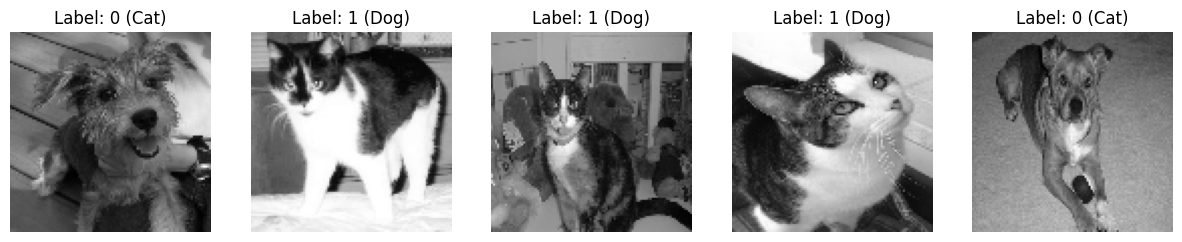

In [21]:
# Visual Inspection and Label Verification

plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)

    # X_subset is (500, 100, 100, 1), we reshape to (100, 100) for visualization

    plt.imshow(X_subset[i].reshape(100, 100), cmap='gray')
    label = "Dog" if y_subset[i] == 1 else "Cat"
    plt.title(f"Label: {y_subset[i]} ({label})")
    plt.axis('off')
plt.show()

## CNN Architecture & Compilation

### Train_Test Split

In [22]:
# Train-Test Split (80/20 split)

X_train, X_test, y_train, y_test = train_test_split(
    X_subset, y_subset, test_size=0.20, random_state=42
)

In [24]:
# Build the Sequential Model

model = Sequential()
model

<Sequential name=sequential_1, built=False>

In [25]:
# Adding Convolutional Blocks

# Block 1
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(100, 100, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
# Define the Output Layer

model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))

In [27]:
# Compiling the Engine

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        33,857 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,673 (205.75 KB)

 Trainable params: 52,673 (205.75 KB)

 Non-trainable params: 0 (0.00 B)

## Training and Prediction

### Fitting The Model

In [28]:
# Fit the Model

history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    batch_size=32
    )

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 360ms/step - accuracy: 0.5050 - loss: 0.6938 - val_accuracy: 0.4900 - val_loss: 0.6933
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 334ms/step - accuracy: 0.5075 - loss: 0.6932 - val_accuracy: 0.4900 - val_loss: 0.6932
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 430ms/step - accuracy: 0.4825 - loss: 0.6932 - val_accuracy: 0.5100 - val_loss: 0.6931
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 363ms/step - accuracy: 0.4725 - loss: 0.6932 - val_accuracy: 0.4900 - val_loss: 0.6932
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 443ms/step - accuracy: 0.5075 - loss: 0.6931 - val_accuracy: 0.4900 - val_loss: 0.6932
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 335ms/step - accuracy: 0.5075 - loss: 0.6932 - val_accuracy: 0.4900 - val_loss: 0.6932
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 334ms/step - accuracy: 0.5075 - loss: 0.6932 - val_accuracy: 0.4900 - val_loss: 0.6932
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 455ms/step - accuracy: 0.5075 - loss: 0.6931 - val_accuracy: 0.

In [29]:
# Evaluate Performance

loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {accuracy*100:.2f}%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.4900 - loss: 0.6932

Test Accuracy: 49.00%


In [30]:
# External Prediction Function

def predict_external_image(image_url, current_model):

    # Download and read the image

    req = urllib.request.urlopen(image_url)
    arr = np.asarray(bytearray(req.read()), dtype=np.uint8)
    img = cv2.imdecode(arr, cv2.IMREAD_GRAYSCALE) # Read as grayscale

    # Resize to 100x100 to match model input

    img_resized = cv2.resize(img, (100, 100))

    # Scale and reshape to 4D array (1, 100, 100, 1)

    img_scaled = img_resized / 255.0
    img_reshaped = img_scaled.reshape(1, 100, 100, 1)

    # Predict

    prediction = current_model.predict(img_reshaped)[0][0]
    predicted_class = "Dog" if prediction > 0.5 else "Cat"

    plt.imshow(img_resized, cmap='gray')
    plt.title(f"Prediction: {predicted_class} (Prob: {prediction:.4f})")
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


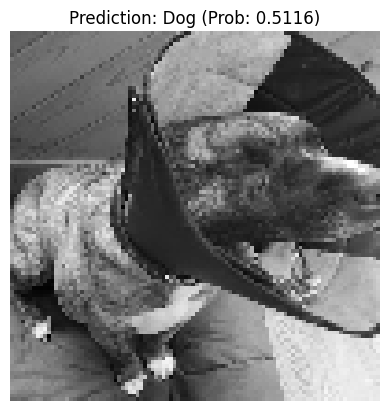

In [31]:
# Test the function with the provided dog image

dog_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg"
predict_external_image(dog_url, model)

## Pass 1 Analytical Review

In [32]:
# Generate predictions for the test set

test_predictions = model.predict(X_test).flatten()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


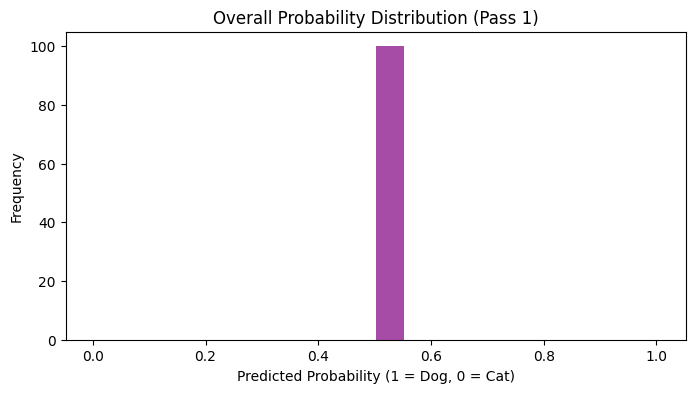

In [33]:
# Probability Distributions

plt.figure(figsize=(8, 4))
plt.hist(test_predictions, bins=20, color='purple', alpha=0.7)
plt.title("Overall Probability Distribution (Pass 1)")
plt.xlabel("Predicted Probability (1 = Dog, 0 = Cat)")
plt.ylabel("Frequency")
plt.show()

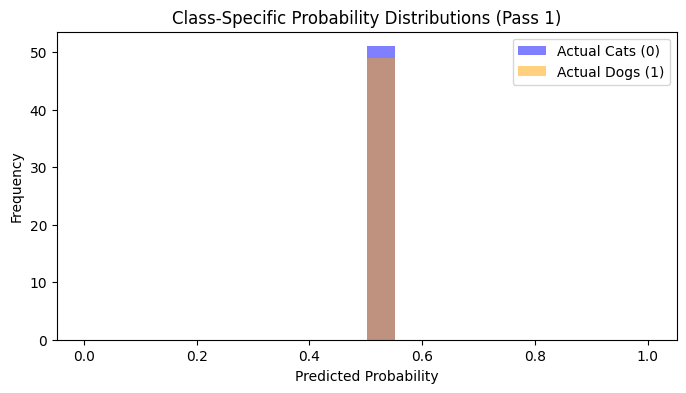

In [34]:
# Class-Specific Distributions

plt.figure(figsize=(8, 4))
plt.hist(test_predictions[y_test == 0], bins=20, color='blue', alpha=0.5, label='Actual Cats (0)')
plt.hist(test_predictions[y_test == 1], bins=20, color='orange', alpha=0.5, label='Actual Dogs (1)')
plt.title("Class-Specific Probability Distributions (Pass 1)")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [35]:
# High-Confidence False Positives (Predicted Cat, Actually Dog)

false_cats = np.where((y_test == 1) & (test_predictions < 0.1))[0]
print(f"Number of high-confidence false cats: {len(false_cats)}")

Number of high-confidence false cats: 0


In [36]:
# High-Confidence False Negatives (Predicted Dog, Actually Cat)

false_dogs = np.where((y_test == 0) & (test_predictions > 0.9))[0]
print(f"Number of high-confidence false dogs: {len(false_dogs)}")

Number of high-confidence false dogs: 0


In [37]:
# Visualizing Oddities (Plotting the errors)

if len(false_cats) > 0:
    plt.imshow(X_test[false_cats[0]].reshape(100, 100), cmap='gray')
    plt.title(f"Actually Dog, Predicted Cat (Prob: {test_predictions[false_cats[0]]:.4f})")
    plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


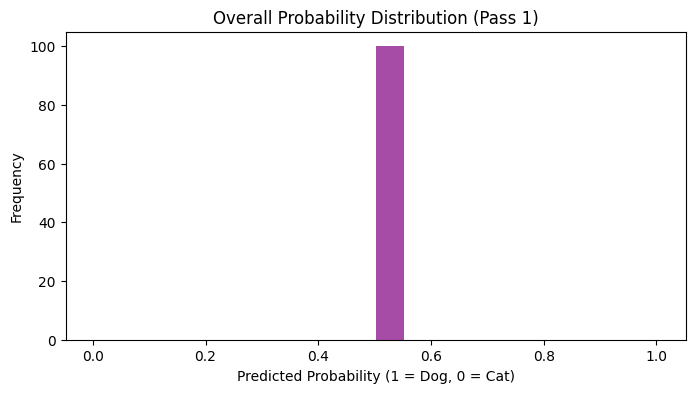

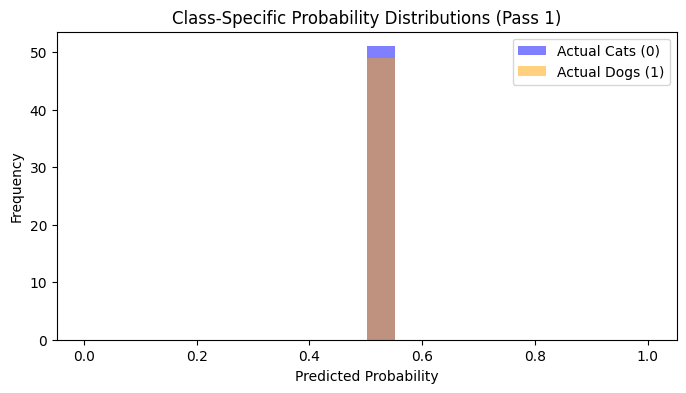


Number of high-confidence false cats: 0

Number of high-confidence false dogs: 0



In [41]:
# Generate predictions for the test set
test_predictions = model.predict(X_test).flatten()

# Probability Distributions

plt.figure(figsize=(8, 4))
plt.hist(test_predictions, bins=20, color='purple', alpha=0.7)
plt.title("Overall Probability Distribution (Pass 1)")
plt.xlabel("Predicted Probability (1 = Dog, 0 = Cat)")
plt.ylabel("Frequency")
plt.show()

# Class-Specific Distributions

plt.figure(figsize=(8, 4))
plt.hist(test_predictions[y_test == 0], bins=20, color='blue', alpha=0.5, label='Actual Cats (0)')
plt.hist(test_predictions[y_test == 1], bins=20, color='orange', alpha=0.5, label='Actual Dogs (1)')
plt.title("Class-Specific Probability Distributions (Pass 1)")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# High-Confidence False Positives (Predicted Cat, Actually Dog)

false_cats = np.where((y_test == 1) & (test_predictions < 0.1))[0]
print(f"\nNumber of high-confidence false cats: {len(false_cats)}\n")

# High-Confidence False Negatives (Predicted Dog, Actually Cat)

false_dogs = np.where((y_test == 0) & (test_predictions > 0.9))[0]
print(f"Number of high-confidence false dogs: {len(false_dogs)}\n")

# Visualizing Oddities (Plotting the errors)

if len(false_cats) > 0:
    plt.imshow(X_test[false_cats[0]].reshape(100, 100), cmap='gray')
    plt.title(f"Actually Dog, Predicted Cat (Prob: {test_predictions[false_cats[0]]:.4f})")
    plt.show()

## Hyperparameter Experimentation

In [42]:
# Experimental Model: Adding a layer, increasing nodes, changing activation to 'elu'

exp_model = Sequential()

# Block 1

exp_model.add(Conv2D(64, kernel_size=(3, 3), activation='elu', input_shape=(100, 100, 1)))
exp_model.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2

exp_model.add(Conv2D(128, kernel_size=(3, 3), activation='elu'))
exp_model.add(MaxPooling2D(pool_size=(2, 2)))

# Block 3 (New)

exp_model.add(Conv2D(128, kernel_size=(3, 3), activation='elu'))
exp_model.add(MaxPooling2D(pool_size=(2, 2)))

# Output Layer

exp_model.add(Flatten())
exp_model.add(Dense(1, activation='sigmoid'))

exp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the experimental model

exp_history = exp_model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), batch_size=32)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.4800 - loss: 0.6967 - val_accuracy: 0.4900 - val_loss: 0.6937
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.4825 - loss: 0.6945 - val_accuracy: 0.4900 - val_loss: 0.6936
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.4625 - loss: 0.6950 - val_accuracy: 0.5100 - val_loss: 0.6946
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.4875 - loss: 0.6946 - val_accuracy: 0.5100 - val_loss: 0.6929
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.5175 - loss: 0.7002 - val_accuracy: 0.4900 - val_loss: 0.6939
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.4825 - loss: 0.6957 - val_accuracy: 0.4900 - val_loss: 0.7038
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.4925 - loss: 0.6973 - val_accuracy: 0.4900 - val_loss: 0.6939
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.4925 - loss: 0.6988 - val_accuracy: 0.5100 - val_loss: